In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (891, 12)


In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

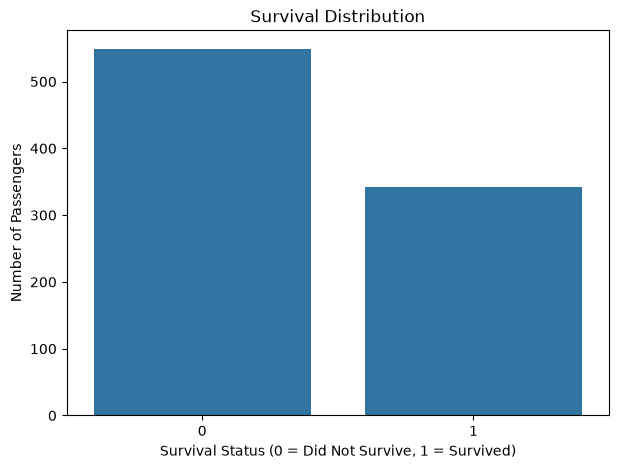

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Number of Passengers")

plt.show()

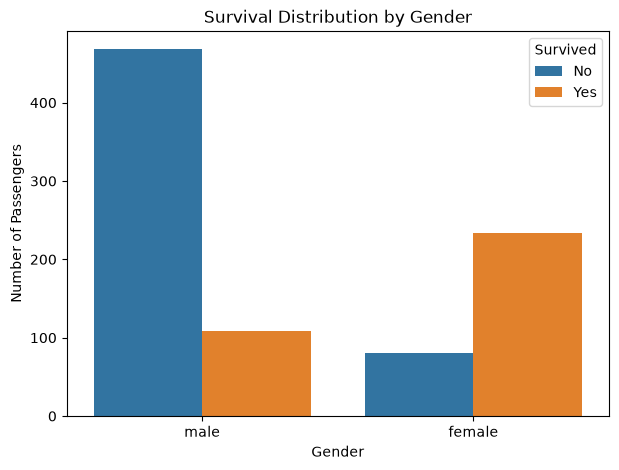

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

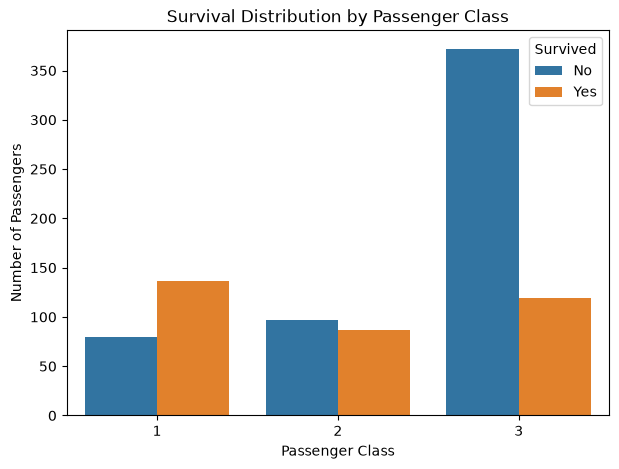

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

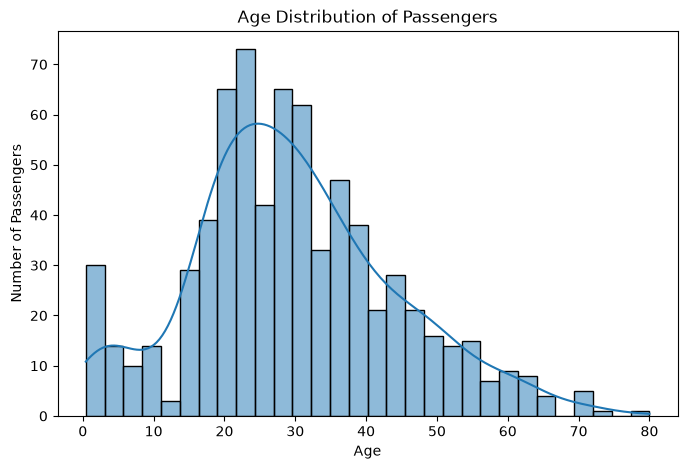

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

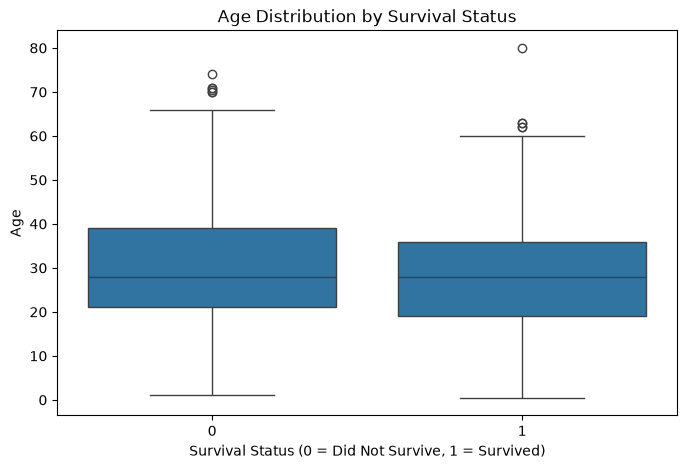

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Survived", y="Age")

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Age")

plt.show()

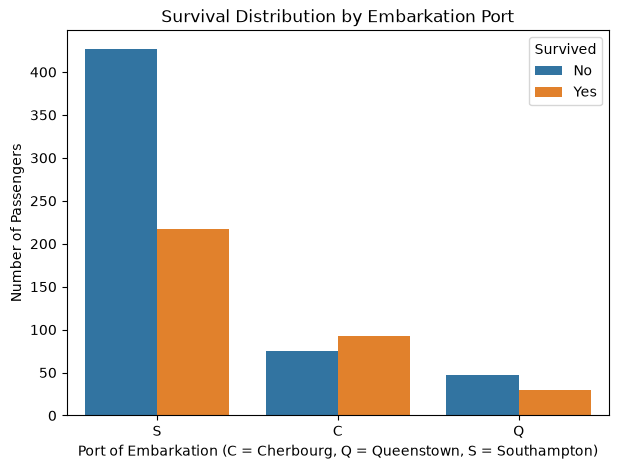

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Embarked", hue="Survived")

plt.title("Survival Distribution by Embarkation Port")
plt.xlabel("Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

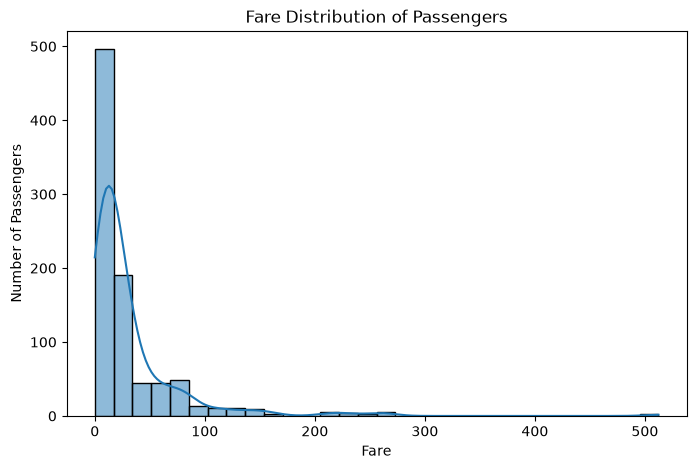

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Fare Distribution of Passengers")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

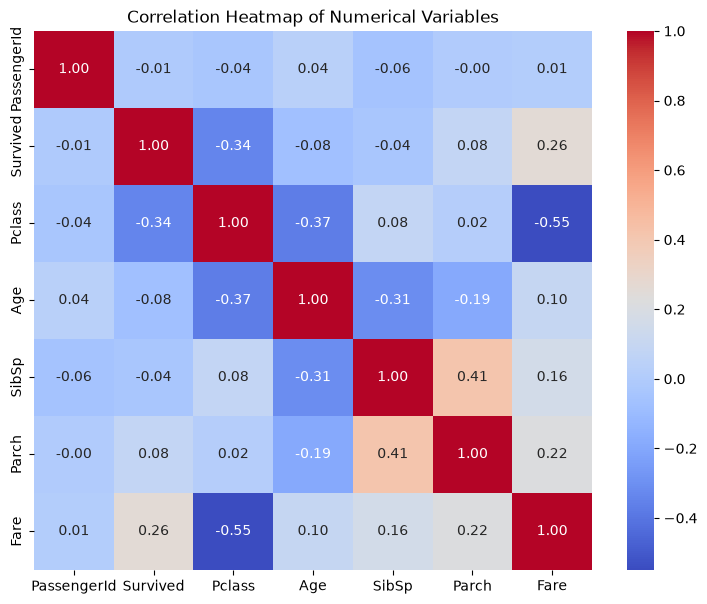

In [14]:
plt.figure(figsize=(9, 7))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


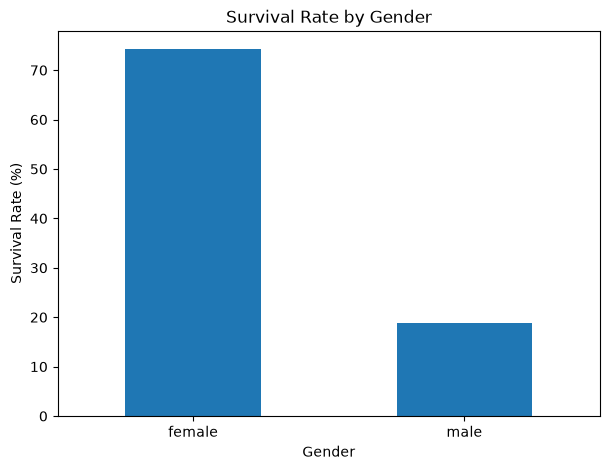

In [15]:
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100

print(survival_by_sex)

plt.figure(figsize=(7, 5))
survival_by_sex.plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


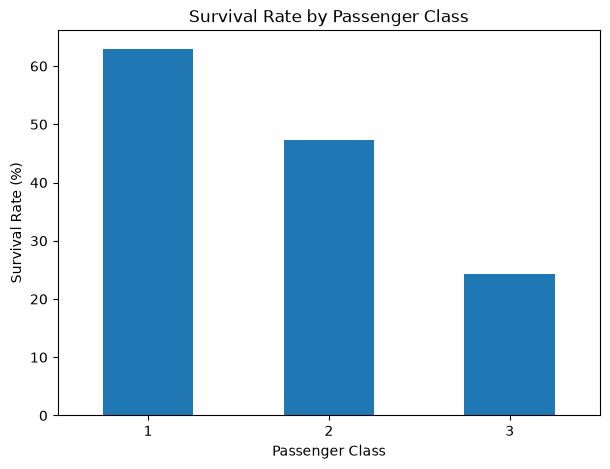

In [16]:
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100

print(survival_by_class)

plt.figure(figsize=(7, 5))
survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


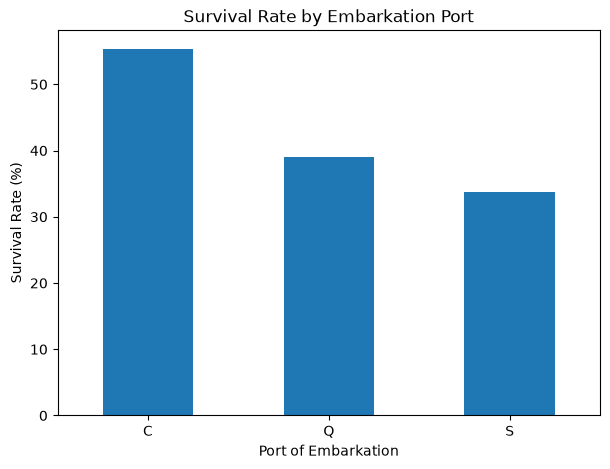

In [17]:
survival_by_port = df.groupby("Embarked")["Survived"].mean() * 100

print(survival_by_port)

plt.figure(figsize=(7, 5))
survival_by_port.plot(kind="bar")

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Port of Embarkation")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.555556
Adult          42.323651
Senior         34.375000
Name: Survived, dtype: float64


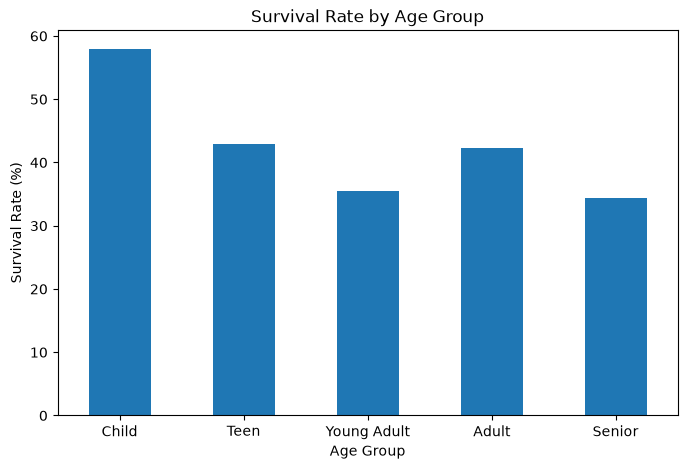

In [18]:
# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

age_survival = df.groupby("AgeGroup", observed=True)["Survived"].mean() * 100

print(age_survival)

plt.figure(figsize=(8, 5))
age_survival.plot(kind="bar")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


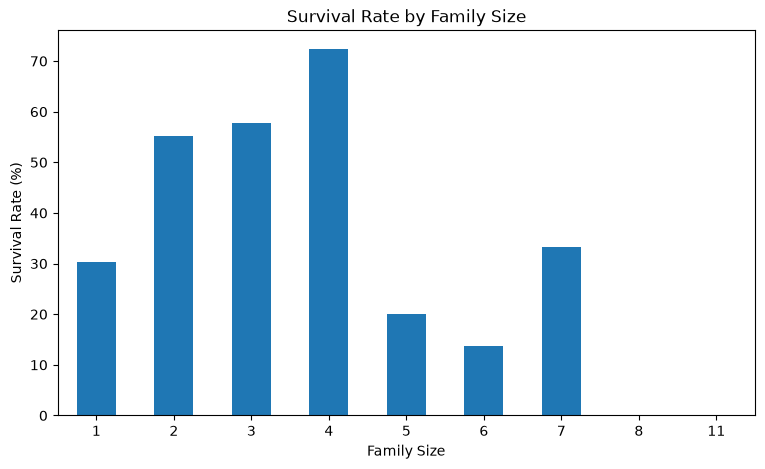

In [19]:
# Create family size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

family_survival = df.groupby("FamilySize")["Survived"].mean() * 100

print(family_survival)

plt.figure(figsize=(9, 5))
family_survival.plot(kind="bar")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

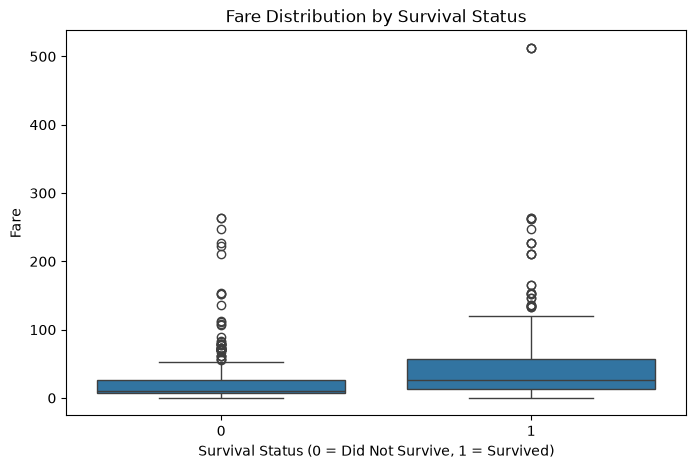

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Survived", y="Fare")

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Fare")

plt.show()

In [21]:
# Check categorical columns
print("Sex values:")
print(df["Sex"].value_counts())

print("\nEmbarked values:")
print(df["Embarked"].value_counts())

print("\nCabin missing percentage:")
print(df["Cabin"].isnull().mean() * 100)

# Fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Create Cabin information feature
df["CabinKnown"] = df["Cabin"].notnull().astype(int)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Sex values:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked values:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Cabin missing percentage:
77.10437710437711

Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
AgeGroup       177
FamilySize       0
CabinKnown       0
dtype: int64


In [22]:
# Recreate AgeGroup after filling missing Age
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

# Check missing values
print("Missing values after final cleaning:")
print(df.isnull().sum())

# Final dataset information
print("\nFinal Dataset Shape:", df.shape)

print("\nFinal Dataset Columns:")
print(df.columns.tolist())

Missing values after final cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
AgeGroup         0
FamilySize       0
CabinKnown       0
dtype: int64

Final Dataset Shape: (891, 15)

Final Dataset Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup', 'FamilySize', 'CabinKnown']


Survival Rate by Gender and Passenger Class:
Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64


<Figure size 900x500 with 0 Axes>

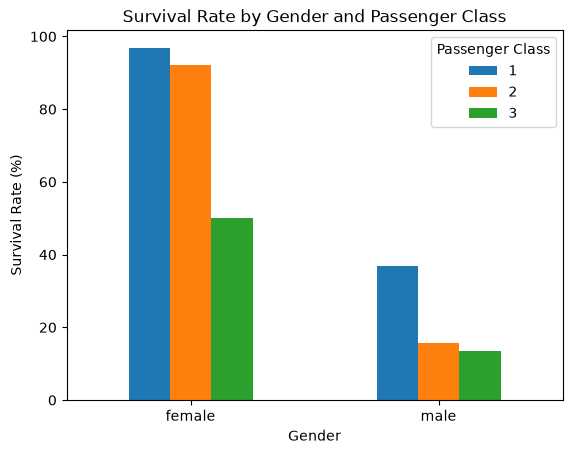

In [23]:
# Survival rate by Gender and Passenger Class
gender_class_survival = df.groupby(["Sex", "Pclass"])["Survived"].mean() * 100

print("Survival Rate by Gender and Passenger Class:")
print(gender_class_survival)

plt.figure(figsize=(9, 5))
gender_class_survival.unstack().plot(kind="bar")

plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Passenger Class")

plt.show()

Survival Rate by Family Category:
FamilyCategory
Alone            30.353818
Small Family     57.876712
Medium Family    20.408163
Large Family      0.000000
Name: Survived, dtype: float64


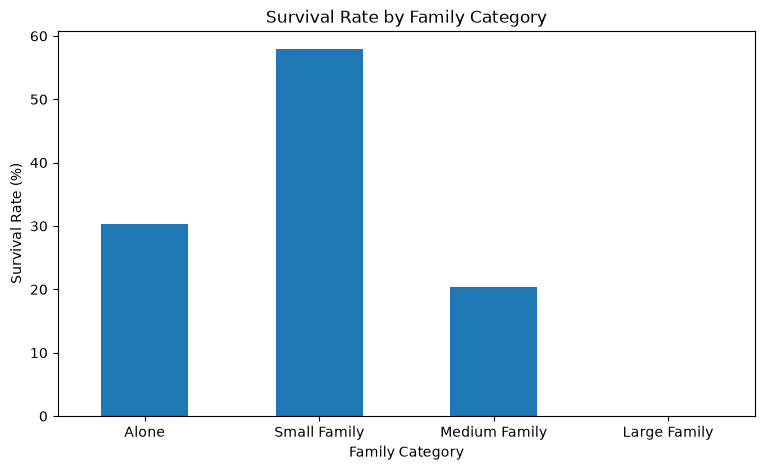

In [24]:
# Create family size categories
df["FamilyCategory"] = pd.cut(
    df["FamilySize"],
    bins=[0, 1, 4, 7, 20],
    labels=["Alone", "Small Family", "Medium Family", "Large Family"]
)

family_category_survival = df.groupby(
    "FamilyCategory", observed=True
)["Survived"].mean() * 100

print("Survival Rate by Family Category:")
print(family_category_survival)

plt.figure(figsize=(9, 5))
family_category_survival.plot(kind="bar")

plt.title("Survival Rate by Family Category")
plt.xlabel("Family Category")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [25]:
print("========== TITANIC EDA SUMMARY ==========")

print("\nOverall Survival Rate:")
print(round(df["Survived"].mean() * 100, 2), "%")

print("\nSurvival Rate by Gender:")
print((df.groupby("Sex")["Survived"].mean() * 100).round(2))

print("\nSurvival Rate by Passenger Class:")
print((df.groupby("Pclass")["Survived"].mean() * 100).round(2))

print("\nSurvival Rate by Embarkation Port:")
print((df.groupby("Embarked")["Survived"].mean() * 100).round(2))

print("\nSurvival Rate by Age Group:")
print((df.groupby("AgeGroup", observed=True)["Survived"].mean() * 100).round(2))

print("\nSurvival Rate by Family Category:")
print((df.groupby("FamilyCategory", observed=True)["Survived"].mean() * 100).round(2))

========== TITANIC EDA SUMMARY ==========

Overall Survival Rate:
38.38 %

Survival Rate by Gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Survival Rate by Embarkation Port:
Embarked
C    55.36
Q    38.96
S    33.90
Name: Survived, dtype: float64

Survival Rate by Age Group:
AgeGroup
Child          57.97
Teen           42.86
Young Adult    33.11
Adult          42.32
Senior         34.38
Name: Survived, dtype: float64

Survival Rate by Family Category:
FamilyCategory
Alone            30.35
Small Family     57.88
Medium Family    20.41
Large Family      0.00
Name: Survived, dtype: float64


In [26]:
from IPython.display import Markdown, display

display(Markdown("""
# Titanic Dataset — EDA Findings

## Key Findings

1. The overall survival rate was **38.38%**.
2. **Female passengers had a much higher survival rate (74.20%)** than male passengers (18.89%).
3. Passenger class strongly influenced survival:
   - 1st Class: **62.96%**
   - 2nd Class: **47.28%**
   - 3rd Class: **24.24%**
4. The combination of gender and passenger class showed a strong difference:
   - Female + 1st Class: **96.81%**
   - Male + 3rd Class: **13.54%**
5. Passengers travelling in a **small family** had the highest survival rate among the family categories (**57.88%**).
6. Children had the highest survival rate among the defined age groups (**57.97%**).
7. The Fare analysis indicates that survivors generally had higher fares than non-survivors.

## Conclusion

The EDA suggests that **gender, passenger class, family size, age group, and fare were important factors associated with Titanic passenger survival**.
"""))


# Titanic Dataset — EDA Findings

## Key Findings

1. The overall survival rate was **38.38%**.
2. **Female passengers had a much higher survival rate (74.20%)** than male passengers (18.89%).
3. Passenger class strongly influenced survival:
   - 1st Class: **62.96%**
   - 2nd Class: **47.28%**
   - 3rd Class: **24.24%**
4. The combination of gender and passenger class showed a strong difference:
   - Female + 1st Class: **96.81%**
   - Male + 3rd Class: **13.54%**
5. Passengers travelling in a **small family** had the highest survival rate among the family categories (**57.88%**).
6. Children had the highest survival rate among the defined age groups (**57.97%**).
7. The Fare analysis indicates that survivors generally had higher fares than non-survivors.

## Conclusion

The EDA suggests that **gender, passenger class, family size, age group, and fare were important factors associated with Titanic passenger survival**.


In [27]:
# Final dataset preview
print("Final Dataset Shape:", df.shape)

display(df.head(10))

print("\nFinal Data Types:")
print(df.dtypes)

Final Dataset Shape: (891, 16)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FamilySize,CabinKnown,FamilyCategory
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young Adult,2,0,Small Family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,2,1,Small Family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young Adult,1,0,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,2,1,Small Family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult,1,0,Alone
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q,Young Adult,1,0,Alone
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Senior,1,1,Alone
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Child,5,0,Medium Family
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Young Adult,3,0,Small Family
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Teen,2,0,Small Family



Final Data Types:
PassengerId          int64
Survived             int64
Pclass               int64
Name                   str
Sex                    str
Age                float64
SibSp                int64
Parch                int64
Ticket                 str
Fare               float64
Cabin                  str
Embarked               str
AgeGroup          category
FamilySize           int64
CabinKnown           int64
FamilyCategory    category
dtype: object


In [28]:
# Final dataset check

print("FINAL DATASET CHECK")
print("===================")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

FINAL DATASET CHECK
Rows: 891
Columns: 16

Missing values:
PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            0
AgeGroup            0
FamilySize          0
CabinKnown          0
FamilyCategory      0
dtype: int64

Duplicate rows: 0


In [29]:
# Final important statistics

print("FINAL TITANIC STATISTICS")
print("========================")

print(f"Overall Survival Rate: {df['Survived'].mean() * 100:.2f}%")

print(f"\nHighest Gender Survival Rate:")
gender_rates = df.groupby("Sex")["Survived"].mean() * 100
print(gender_rates.round(2))

print(f"\nPassenger Class Survival Rate:")
class_rates = df.groupby("Pclass")["Survived"].mean() * 100
print(class_rates.round(2))

print(f"\nEmbarkation Survival Rate:")
port_rates = df.groupby("Embarked")["Survived"].mean() * 100
print(port_rates.round(2))

FINAL TITANIC STATISTICS
Overall Survival Rate: 38.38%

Highest Gender Survival Rate:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Passenger Class Survival Rate:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Embarkation Survival Rate:
Embarked
C    55.36
Q    38.96
S    33.90
Name: Survived, dtype: float64


In [30]:
from IPython.display import Markdown, display

display(Markdown("""
# Final Conclusion

The Titanic dataset was successfully explored and cleaned using Python, Pandas, Matplotlib, and Seaborn.

### Major Observations

- Overall survival rate was **38.38%**.
- Female passengers had a considerably higher survival rate than male passengers.
- **1st-class passengers** had the highest survival rate, while 3rd-class passengers had the lowest.
- The combination of **gender and passenger class** showed a strong difference in survival.
- Small-family passengers showed a higher survival rate than passengers travelling alone or in larger families.
- Children showed the highest survival rate among the defined age groups.
- Survivors generally had higher fare values than non-survivors.

### Final Statement

The analysis shows that passenger characteristics such as **gender, passenger class, age group, family size, embarkation port, and fare were associated with survival outcomes** in the Titanic dataset.
"""))


# Final Conclusion

The Titanic dataset was successfully explored and cleaned using Python, Pandas, Matplotlib, and Seaborn.

### Major Observations

- Overall survival rate was **38.38%**.
- Female passengers had a considerably higher survival rate than male passengers.
- **1st-class passengers** had the highest survival rate, while 3rd-class passengers had the lowest.
- The combination of **gender and passenger class** showed a strong difference in survival.
- Small-family passengers showed a higher survival rate than passengers travelling alone or in larger families.
- Children showed the highest survival rate among the defined age groups.
- Survivors generally had higher fare values than non-survivors.

### Final Statement

The analysis shows that passenger characteristics such as **gender, passenger class, age group, family size, embarkation port, and fare were associated with survival outcomes** in the Titanic dataset.
